En este notebook se realiza la carga inicial del dataset de calidad del agua potable obtenido desde Kaggle. El objetivo es comprender la estructura de los datos, identificar las variables disponibles, revisar valores nulos, tipos de datos, estadísticas generales y la distribución de la variable objetivo Potability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar el dataset 
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Descripción de las variables

El dataset contiene variables fisicoquímicas relacionadas con la calidad del agua. Cada fila representa una muestra de agua y cada columna representa una medición realizada sobre esa muestra.

### Variables independientes

- ph
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic_carbon
- Trihalomethanes
- Turbidity

### Variable dependiente
- Potability - 0 = No potable, 1 = Potable 

| Variable | Unidad en el dataset | Criterio que representa |
|---|---|---|
| `ph` | Escala de pH, de 0 a 14 | Mide el equilibrio ácido-base del agua. Valores bajos indican acidez y valores altos indican alcalinidad. |
| `Hardness` | mg/L | Mide la dureza del agua, principalmente asociada a calcio y magnesio disueltos. |
| `Solids` | ppm | Mide los sólidos disueltos totales en el agua. Valores altos indican mayor mineralización. |
| `Chloramines` | ppm | Mide la cantidad de cloraminas presentes, usadas como desinfectantes en el agua. |
| `Sulfate` | mg/L | Mide la concentración de sulfatos disueltos en el agua. |
| `Conductivity` | μS/cm | Mide la capacidad del agua para conducir electricidad, asociada a la presencia de iones disueltos. |
| `Organic_carbon` | ppm | Mide la cantidad de carbono orgánico total presente en el agua. |
| `Trihalomethanes` | μg/L | Mide la concentración de trihalometanos, compuestos que pueden aparecer como subproductos de la desinfección. |
| `Turbidity` | NTU | Mide la turbidez del agua, es decir, la dispersión de luz causada por partículas suspendidas. |

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
# Tamaño del dataset
df.shape

(3276, 10)

In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

## Revisión de nulos

In [8]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [9]:
df.isnull().sum() / len(df) * 100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [10]:
(df['Sulfate'] == 0).sum()

np.int64(0)

In [11]:
(df['ph'] == 0).sum()

np.int64(1)

In [12]:
(df['Trihalomethanes'] == 0).sum()

np.int64(0)

In [9]:
(df['Trihalomethanes'] <= 1).sum()

np.int64(1)

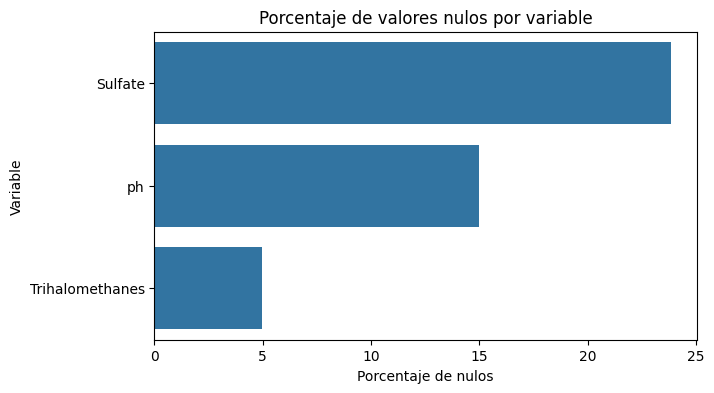

In [24]:
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
nulos_porcentaje = nulos_porcentaje[nulos_porcentaje > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=nulos_porcentaje.values, y=nulos_porcentaje.index)

plt.title('Porcentaje de valores nulos por variable')
plt.xlabel('Porcentaje de nulos')
plt.ylabel('Variable')

plt.show()

- Los nulos estan bastante presentes en las columnas Sulfato y ph, por lo que eliminar muestras con nulos queda descartado en ese aspecto.
- En el caso de ph, reemplazarlo por 0 parece incorrecto ya que ese valor para las muestras de agua es muy inusual.
- Tambien no es factible reemplazar el valor de la columna sulfato con 0 porque el minimo dato presentado en el data set es arriba de 129.
- En cuanto a los Trihalometanos (subproductos de cloro y desinfectantes), en agua no suelen ser 0, por lo que tampoco se puede optar por esta opcion

Debido a que las 3 son variables con importancia media a alta, la siguiente opcion antes de analizar su tratamiento será analizar su correlacion para su posterior tratamiento en la limpieza.

In [10]:
# identificar duplicados
df.duplicated().sum()

np.int64(0)

No existen muestras duplicadas

In [11]:
# Contar el número de muestras de agua potable y no potable
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [12]:
df['Potability'].value_counts(normalize=True) * 100

Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64

Existe un balance aceptable en los valores de esta variable

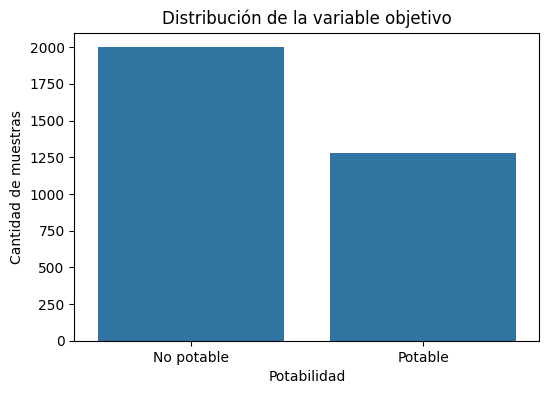

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Potability')

plt.title('Distribución de la variable objetivo')
plt.xlabel('Potabilidad')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['No potable', 'Potable'])

plt.show()

Existen mas muestras del agua no potable.

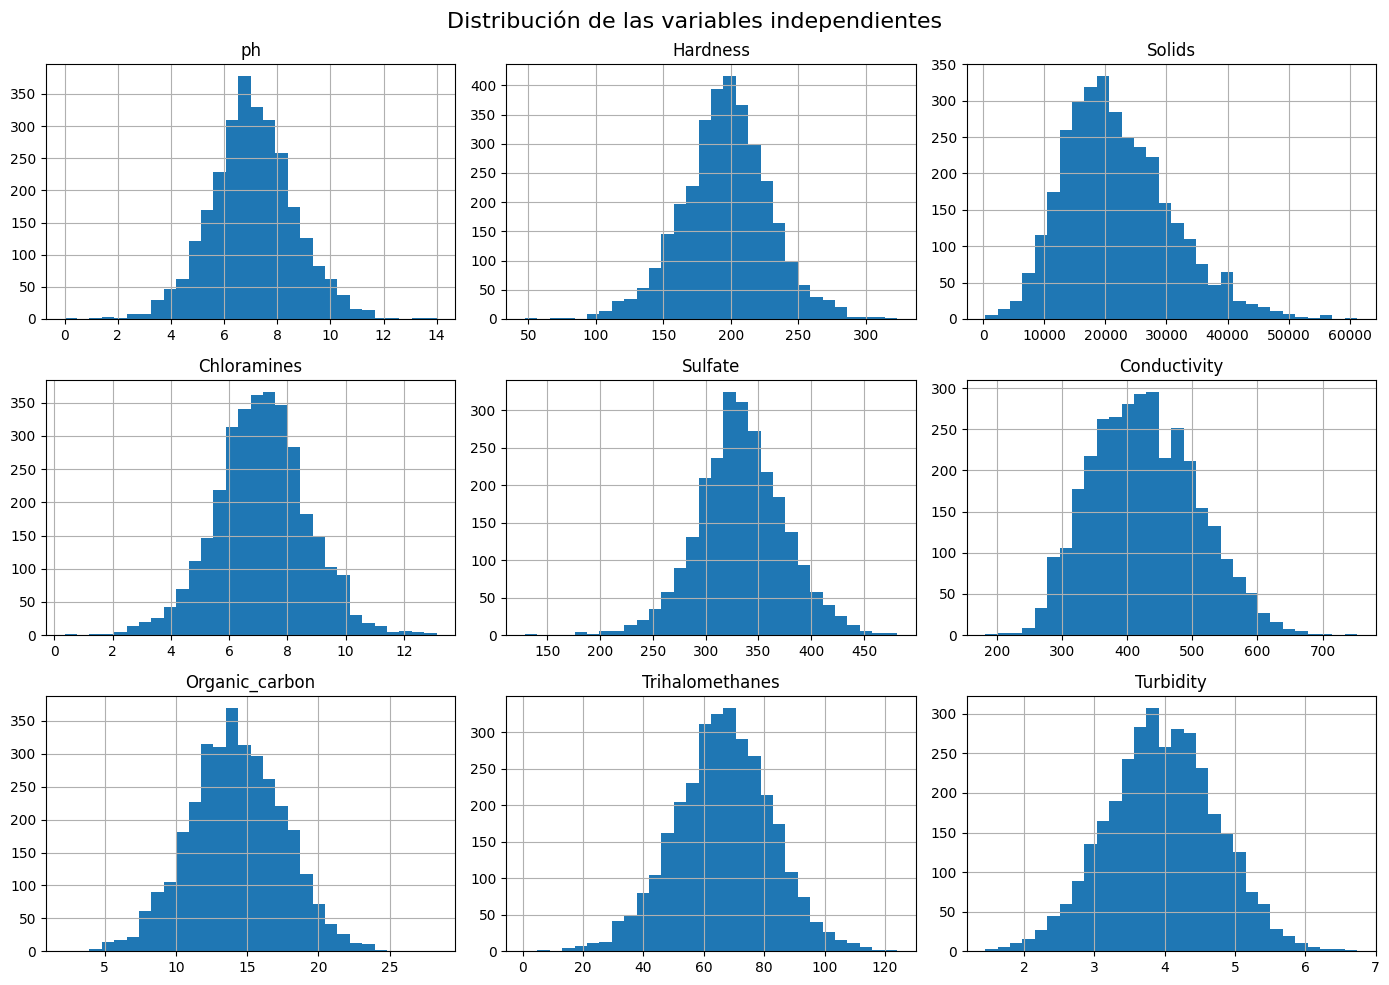

In [ ]:
# Distribución de las variables independientes y sus escalas
variables_independientes = [
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity'
]

df[variables_independientes].hist(figsize=(14, 10), bins=30)

plt.suptitle('Distribución de las variables independientes', fontsize=16)
plt.tight_layout()
plt.show()

### Interpretación de histogramas

- Las variables presentan escalas diferentes.
- `Solids` y `Conductivity` tienen rangos mucho más amplios que variables como `ph` o `Turbidity`.
- Algunas variables muestran valores extremos o distribuciones dispersas.
- Estas diferencias indican que en etapas posteriores puede ser necesario aplicar escalado antes del modelado.

# Diagramas de bigotes

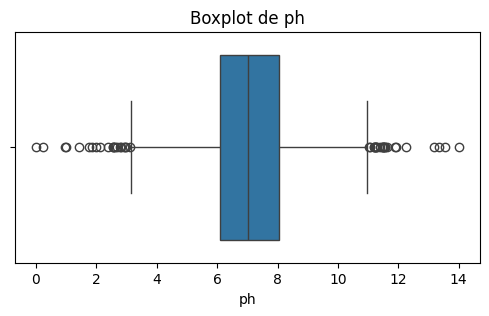

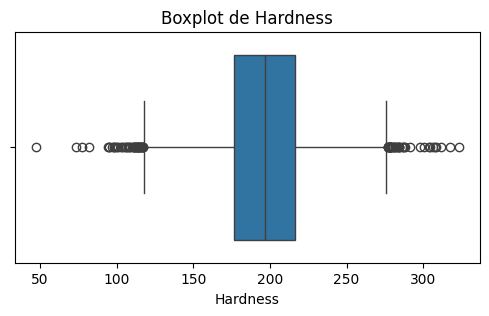

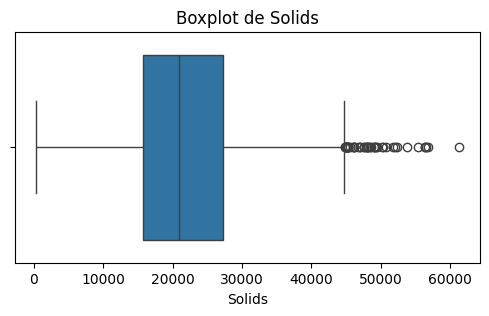

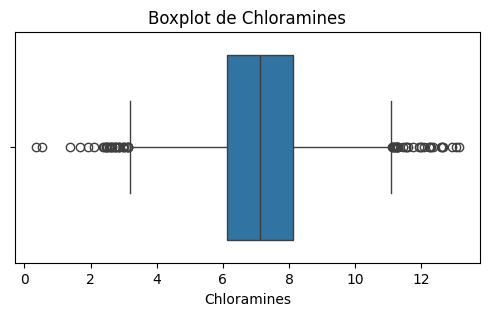

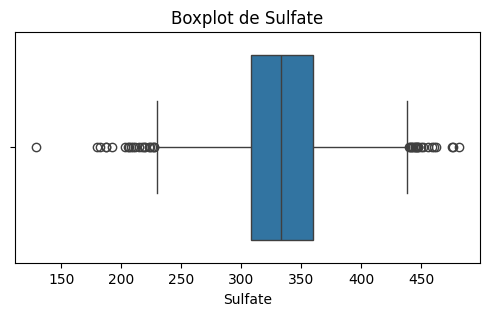

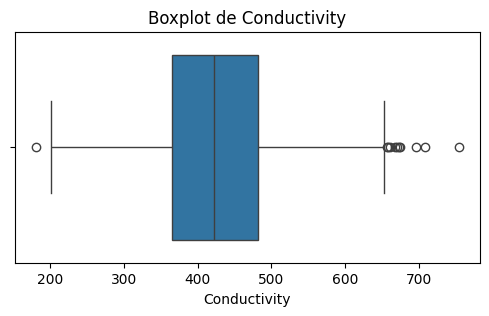

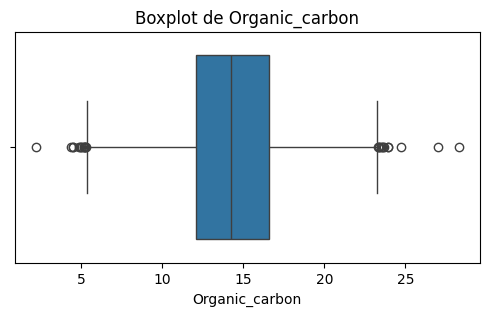

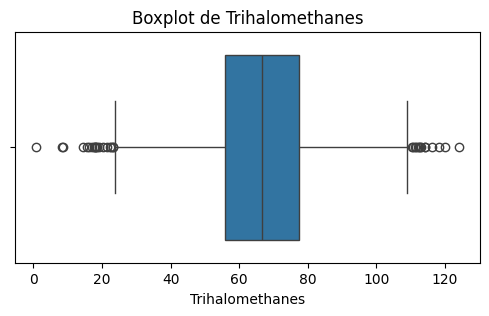

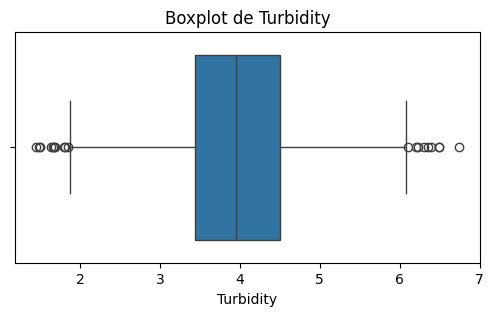

In [16]:
for columna in variables_independientes:
    plt.figure(figsize=(6, 3))
    
    sns.boxplot(data=df, x=columna)
    
    plt.title(f'Boxplot de {columna}')
    plt.xlabel(columna)
    
    plt.show()

Se observan bastantes outliers por lo que habra que analizar si son o no errores para su limpieza.

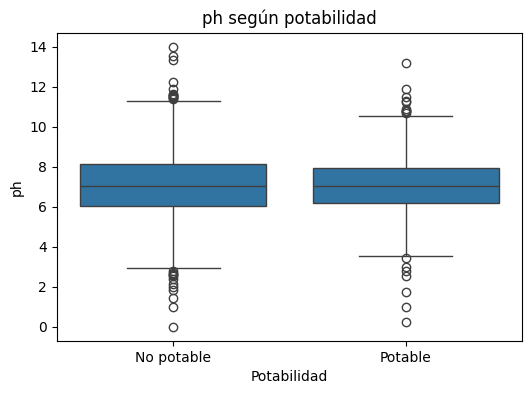

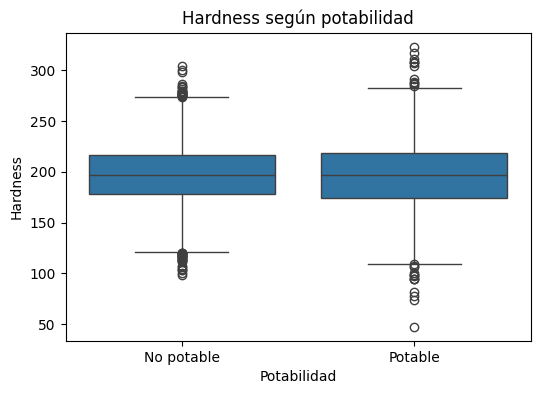

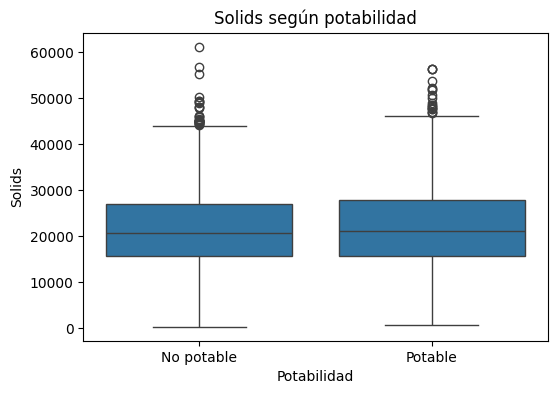

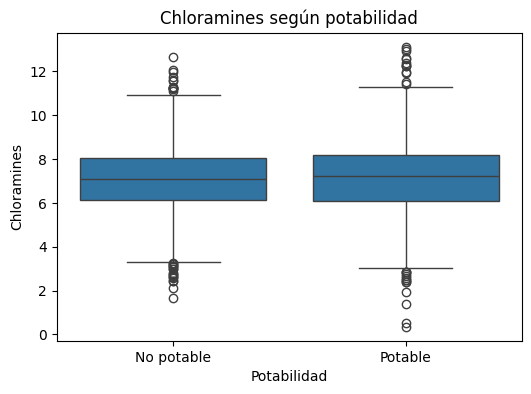

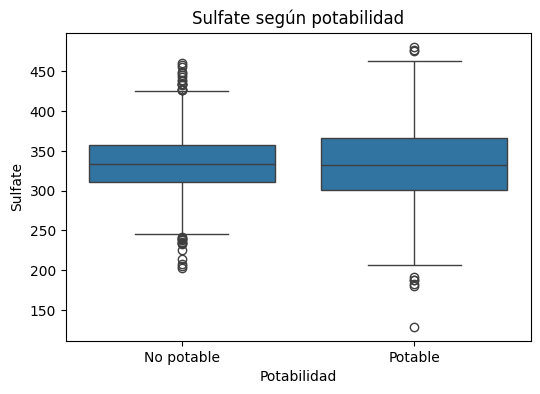

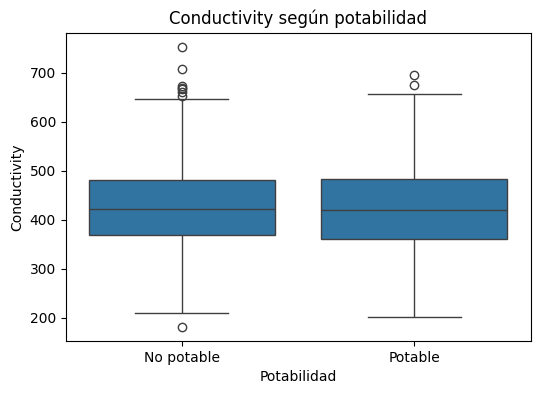

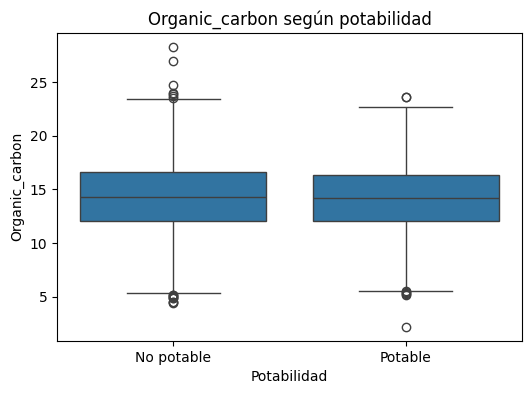

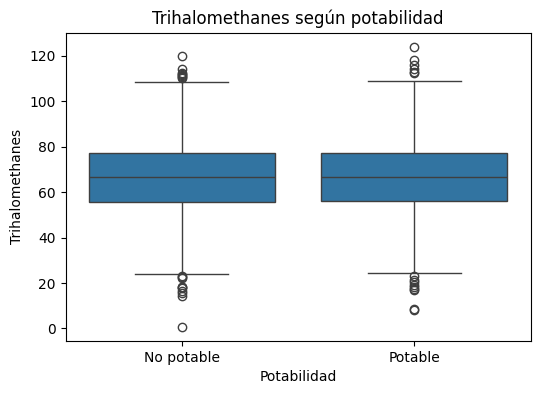

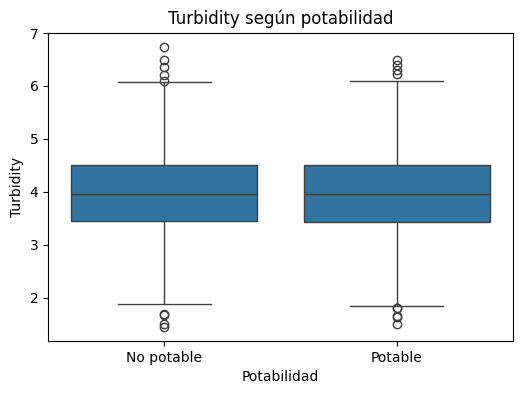

In [17]:
# Comparación de las distribuciones de las variables independientes entre agua potable y no potable
for columna in variables_independientes:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(data=df, x='Potability', y=columna)
    
    plt.title(f'{columna} según potabilidad')
    plt.xlabel('Potabilidad')
    plt.ylabel(columna)
    plt.xticks([0, 1], ['No potable', 'Potable'])
    
    plt.show()

# Variable y Observación en los boxplots 

- `ph` -> Las distribuciones son similares entre agua potable y no potable; existen valores extremos. 
- `Hardness` -> No presenta diferencias claras entre ambas clases. 
- `Solids` -> Tiene alta dispersión y outliers, pero no separa claramente las clases. 
- `Chloramines` -> Las medianas son parecidas en ambos grupos. 
- `Sulfate` -> Presenta valores atípicos y distribuciones similares; además tiene varios nulos. 
- `Conductivity` -> No muestra una diferencia marcada según potabilidad. 
- `Organic_carbon` -> Distribución similar entre muestras potables y no potables. 
- `Trihalomethanes` -> Valores centrales parecidos en ambas clases, con algunos outliers. 
- `Turbidity` -> Distribuciones casi iguales entre ambas clases. 

In [25]:
# Identificacion de outliers:
outliers = {}

for columna in variables_independientes:
    media = df[columna].mean()
    desviacion = df[columna].std()
    
    limite_inferior = media - 3 * desviacion
    limite_superior = media + 3 * desviacion
    
    cantidad_outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ][columna].count()
    
    outliers[columna] = cantidad_outliers

tabla_outliers = pd.DataFrame.from_dict(
    outliers,
    orient='index',
    columns=['Cantidad de posibles outliers']
)

tabla_outliers.sort_values(by='Cantidad de posibles outliers', ascending=False)

,Cantidad de posibles outliers
Solids,20
Chloramines,20
Hardness,18
Sulfate,17
ph,16
Trihalomethanes,12
Turbidity,8
Conductivity,7
Organic_carbon,4


### Identificación de posibles valores atípicos

Para identificar posibles valores atípicos se utilizó un criterio basado en la media y la desviación estándar. Se consideraron como posibles outliers aquellos valores que se encuentran fuera del rango definido por la media más o menos tres desviaciones estándar.

Este análisis permite detectar valores muy alejados del comportamiento general de cada variable. Sin embargo, en esta etapa no se eliminan estos registros, ya que pueden representar mediciones reales de la calidad del agua y deberán analizarse con mayor detalle en la etapa de limpieza.

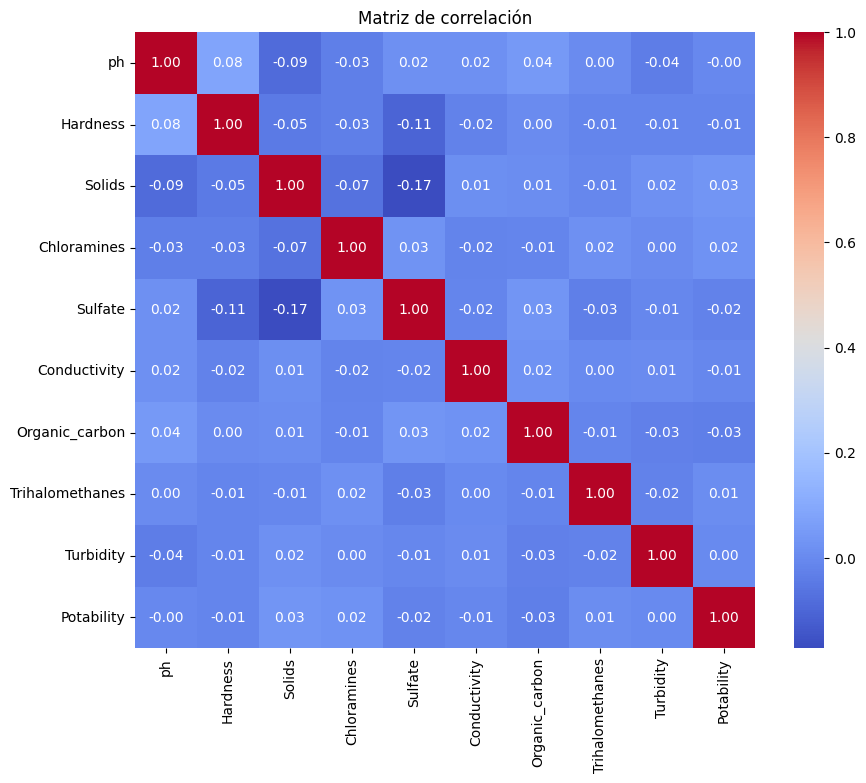

In [18]:
# Matriz de correlación
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()

### Interpretación de la matriz de correlación:

- Las variables no muestran una relación lineal fuerte con `Potability`.
- No hay una variable que explique por sí sola si el agua es potable.
- La clasificación probablemente dependerá de la combinación de varias características.
- Se recomienda probar modelos no lineales simples, como árboles de decisión.

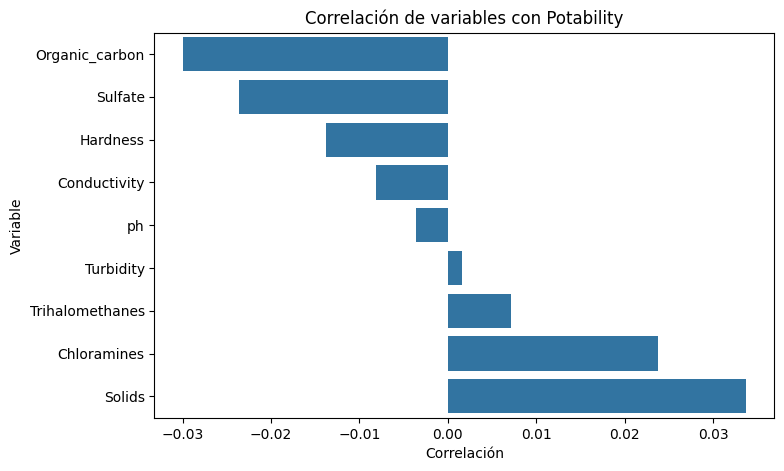

In [26]:
correlacion_potabilidad = df.corr(numeric_only=True)['Potability'].drop('Potability').sort_values()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=correlacion_potabilidad.values,
    y=correlacion_potabilidad.index
)

plt.title('Correlación de variables con Potability')
plt.xlabel('Correlación')
plt.ylabel('Variable')

plt.show()

Todas las variables presentan una correlación lineal muy baja con `Potability`. Esto indica que ninguna variable independiente explica por sí sola la potabilidad del agua mediante una relación lineal directa.

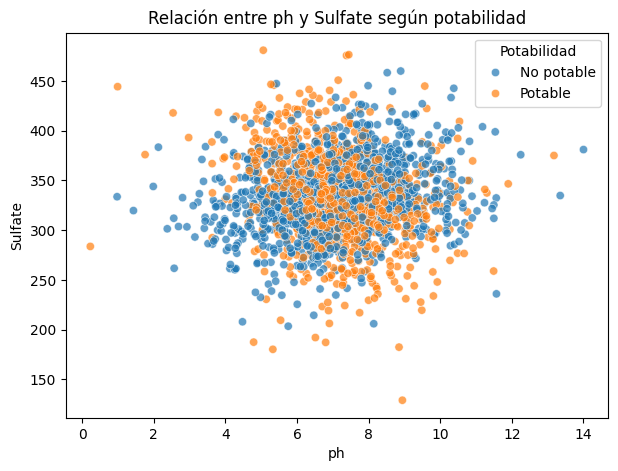

In [21]:
# comparacion entre dos variables y potabilidad segun una relacion quimica posible

# ph vs sulfato
df_grafico = df.copy()

df_grafico['Potabilidad'] = df_grafico['Potability'].map({
    0: 'No potable',
    1: 'Potable'
})

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_grafico,
    x='ph',
    y='Sulfate',
    hue='Potabilidad',
    alpha=0.7
)

plt.title('Relación entre ph y Sulfate según potabilidad')
plt.xlabel('ph')
plt.ylabel('Sulfate')
plt.legend(title='Potabilidad')

plt.show()

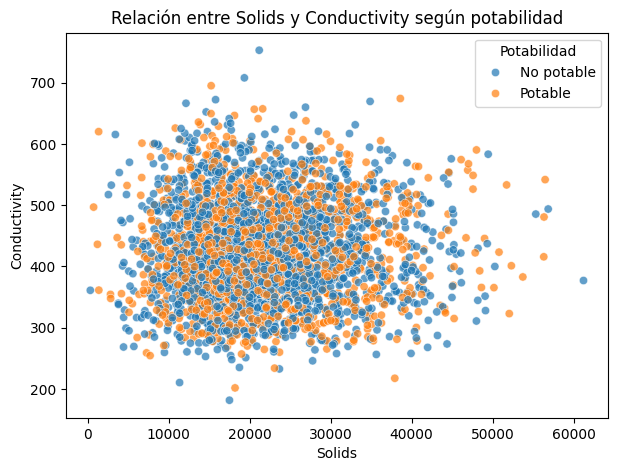

In [22]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_grafico,
    x='Solids',
    y='Conductivity',
    hue='Potabilidad',
    alpha=0.7
)

plt.title('Relación entre Solids y Conductivity según potabilidad')
plt.xlabel('Solids')
plt.ylabel('Conductivity')
plt.legend(title='Potabilidad')

plt.show()

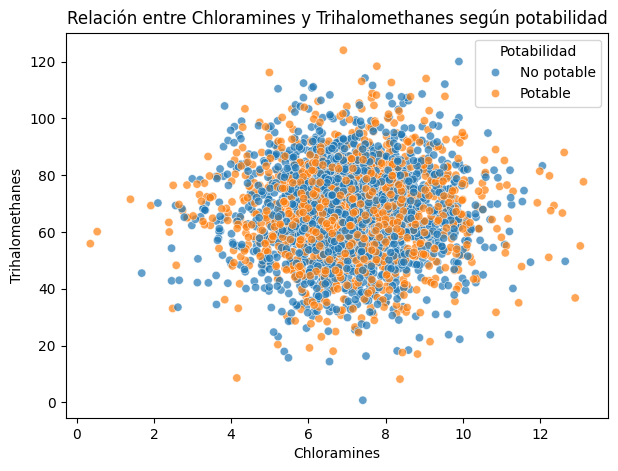

In [23]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_grafico,
    x='Chloramines',
    y='Trihalomethanes',
    hue='Potabilidad',
    alpha=0.7
)

plt.title('Relación entre Chloramines y Trihalomethanes según potabilidad')
plt.xlabel('Chloramines')
plt.ylabel('Trihalomethanes')
plt.legend(title='Potabilidad')

plt.show()

| Par de variables                   | Motivo de comparación                       |
| ---------------------------------- | ------------------------------------------- |
| `ph` vs `Sulfate`                  | Condiciones químicas del agua               |
| `Solids` vs `Conductivity`         | Sustancias disueltas y conducción eléctrica |
| `Chloramines` vs `Trihalomethanes` | Desinfección y subproductos químicos        |


### Conclusión de los gráficos de dispersión

- No se observa una separación visual clara entre muestras potables y no potables.
- Las clases aparecen mezcladas en las tres combinaciones analizadas.
- Esto confirma que la potabilidad no depende de una relación simple entre dos variables.
- Para el modelo será necesario combinar varias variables al mismo tiempo.

## Conclusiones generales del EDA

- El dataset contiene 3276 muestras de agua y variables fisicoquímicas relacionadas con su calidad.
- La variable objetivo `Potability` permite plantear el problema como una clasificación binaria.
- La clase no potable es mayoritaria, pero el desbalance no es crítico.
- Se identificaron valores nulos en `ph`, `Sulfate` y `Trihalomethanes`.
- No se encontraron registros duplicados.
- Se observaron posibles valores atípicos en varias variables, pero no se eliminarán todavía.
- Las variables presentan escalas diferentes, por lo que más adelante podría ser necesario aplicar escalado.
- No se encontraron correlaciones lineales fuertes con `Potability`.
- Los gráficos comparativos muestran que las clases potable y no potable están mezcladas.
- El modelado deberá combinar varias variables para intentar predecir la potabilidad del agua.